To implement the evolution of the states when an external field is coupled to it
- length gauge is used: H = T + V_softcore + E(t)x
- E(t) has a temporal only profile, meaning as the CN operator goes through time steps, the value of E(t) for that step will change
- Also, since we are in the dipole approximation E(t) has NO spatial depedence.
- So, for each of those time steps, the value of E(t) over the entire x_vec spatial range is constant
- Thus, we simply add a constant to the H_diag of the H in CN step
- We are also not in the imaginary time anymore, as eigenstates are already found and we want to note the evolution of said eigenstates through real time.
- Initial state (before external field coupling and CN evolution) is Psi0
- Since coupling frequency (or Energy, as we are in a.u.) is equal to the difference between the first two states, jump from the GS to first eigenstate will be noticed.


In [86]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import sparse
from matplotlib.backends.backend_pdf import PdfPages

def count_nodes(psi):
    return np.sum(np.abs(np.diff(np.sign(psi))) / 2)

# creates the matrices necessary for CN
def create_Apl_Ami_Heff_M2_matrices(r_vec, V_vec, Z, ell, deltaTau):
    Delta_r = r_vec[1] - r_vec[0]
    N = len(r_vec)
    
    D_lower = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_upper = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_diag = -2*np.ones(N, dtype=complex)/(Delta_r**2)
    
    D_11_corr = -2*(1 - (Z*Delta_r)/(12 - 10*Z*Delta_r))/(Delta_r**2)
    if ell == 0:
        D_diag[0] = D_11_corr
    
    D = get_sparseMatrix(D_lower, D_diag, D_upper)
    
    M_2_lower = -np.ones(N-1, dtype=complex)/6
    M_2_diag = -10*np.ones(N, dtype=complex)/6
    M_2_upper = -np.ones(N-1, dtype=complex)/6
    if ell == 0:
        M_2_diag[0] = -2*(1 + (Delta_r**2)*D_11_corr/12)
    M_2 = get_sparseMatrix(M_2_lower, M_2_diag, M_2_upper)
    
    V_matrix = sparse.spdiags([V_vec], [0], N, N)
    
    # Hamiltonian (effective)
    H_2 = D + M_2@V_matrix
    
    # CN A matrices
    A_pl = M_2 + 0.5j * deltaTau * H_2
    A_mi = M_2 - 0.5j * deltaTau * H_2
    return A_pl, A_mi, H_2, M_2

def get_sparseMatrix(upper, mid, lower):
    return sparse.diags([lower, mid, upper], offsets=[-1, 0, 1], format="csr")

# Crank-Nicolson propagation
def CN_propagation(A_pl, A_mi, psi, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)): # Iterate for imaginary time
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r)
    return psi

# Compute energy (expectation value of Hamiltonian)
def calc_E_withNumerov(psi, H_2, M_2, r):
    return project(psi, H_2 @ psi, r)/project(psi, M_2 @ psi, r)


def get_diag(mat):
    return np.array([mat[i, i] for i in range(mat.shape[0])], dtype=complex)
def get_upper(mat):
    return np.array([mat[i-1, i] for i in range(1, mat.shape[0])], dtype=complex)
def get_lower(mat):
    return np.array([mat[i, i-1] for i in range(1, mat.shape[0])], dtype=complex)

# general scalar projection function
def project(psi1, psi2, r_vec):
    return np.trapz(np.conj(psi1)*psi2, x=r_vec)
def normalize(psi, r_vec):
    return psi/np.sqrt(project(psi, psi, r_vec))

def thomas_algorithm(a, b, c, d):
    n = len(b)
    
    # Create copies of the input arrays to modify during elimination
    bp = np.copy(b).astype(complex) # diagonal copy
    dp = np.copy(d).astype(complex) # Right-hand side copy
    
    # Forward elimination
    for i in range(1, n):
        # Modify the coefficients in the sub-diagonal and right-hand side
        w = a[i-1] / bp[i-1]
        bp[i] = b[i] - w * c[i-1]
        dp[i] = d[i] - w * dp[i-1]
    
    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = dp[-1] / bp[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dp[i] - c[i] * x[i+1]) / bp[i]
    return x

In [87]:
psi0 = np.load("psi0.npy")
psi1 = np.load("psi1.npy")
a = 0.00823974609375

# grid details
Delta_r = 0.2
N = 500
r_vec = np.linspace(Delta_r, N * Delta_r, N) 

V_softcore_vec = -1/np.sqrt(r_vec**2 + a**2)

# Real time step (Δt) and time grid
delta_t = 0.1
T = 2000 # in a.u.
t_vec = np.arange(0, T + delta_t, delta_t)

# External field 
E0 = 8e-2
omega = (-0.1256862276 - -0.5000004185) # difference b/w GS and First State
E_t_vec = E0 * np.cos(np.pi * (t_vec - T/2) / T)**2 * np.cos(omega * t_vec)
# plt.plot(t_vec[0:t_vec.size//1], E_t_vec[0:t_vec.size//1])



Trial iteration for one step only, attempt at modification

In [88]:
# EXPORT TO PDF to see time evolution
pdffile = "external-field-evolution-psi-initial.pdf"

with PdfPages(pdffile) as pdf:


    # CALCULATIONS
    # Iterate for 1 step only
    psi = psi0.copy()
    populations0 = np.zeros_like(t_vec)
    populations1 = np.zeros_like(t_vec)

    for iter in range(t_vec.size):
        E_t = E_t_vec[iter] # choosing the field value corresponding to the current time step

        # modify V_l = V_softcore + E(t).x, for the CN matrices
        A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(r_vec, V_softcore_vec + E_t * r_vec, Z=1, ell=0, deltaTau=delta_t)
        
        #CN propagation step
        A_pl_lower = get_lower(A_pl)
        A_pl_diag = get_diag(A_pl)
        A_pl_upper = get_upper(A_pl)
        
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r_vec)
        
        populations0[iter] = project(psi0, psi, r_vec) * np.conj(project(psi0, psi, r_vec))
        populations1[iter] = project(psi1, psi, r_vec) * np.conj(project(psi1, psi, r_vec))
        
        if iter%25==0:
            plt.plot(r_vec, psi0, label = "initial")
            plt.plot(r_vec, psi, label = "evolved")
            plt.legend()
            plt.grid(True)
            plt.title(f"Evolution of the GS under external field, Time step : {iter}")
            plt.ylim(-1, 1)
        
        
            pdf.savefig()
            plt.close()



/tmp/ipykernel_13789/1214038944.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  populations0[iter] = project(psi0, psi, r_vec) * np.conj(project(psi0, psi, r_vec))
/tmp/ipykernel_13789/1214038944.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  populations1[iter] = project(psi1, psi, r_vec) * np.conj(project(psi1, psi, r_vec))
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


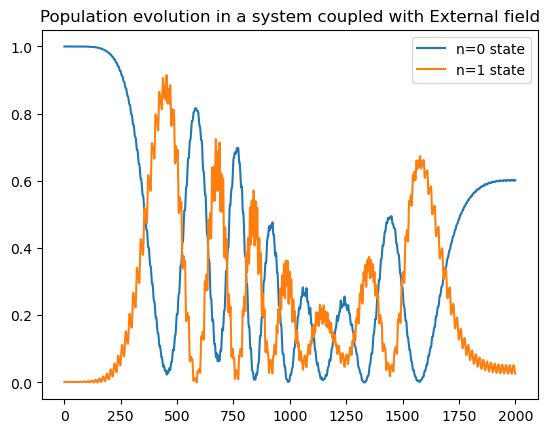

In [89]:
plt.plot(t_vec, populations0, label = "n=0 state")
plt.plot(t_vec, populations1, label = "n=1 state")
plt.title("Population evolution in a system coupled with External field")
plt.legend()